# Movie Review Text Classification

This notebook loads movie review data, cleans text, explores word and n-gram patterns,
trains classification models, performs hyperparameter tuning, and saves the final model.

In [121]:
import pandas as pd


## 1. Load dataset

Read the CSV file and inspect the dataset.

In [122]:
df = pd.read_csv("movie\movie.csv",encoding="latin1")
df

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Alvi\AppData\Local\Temp\ipykernel_14524\818160564.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df = pd.read_csv("movie\movie.csv",encoding="latin1")


,ï»¿text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1
...,...,...
39995,"""Western Union"" is something of a forgotten cl...",1
39996,This movie is an incredible piece of work. It ...,1
39997,My wife and I watched this movie because we pl...,0
39998,"When I first watched Flatliners, I was amazed....",1


In [123]:
df["text"] = df["ï»¿text"]
df.drop(columns="ï»¿text",inplace=True)

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   40000 non-null  int64
 1   text    40000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 50.6 MB


In [125]:
df.describe()

,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [126]:
df.describe(include="str")

,text
count,40000
unique,39723
top,"Hilarious, clean, light-hearted, and quote-wor..."
freq,4


In [127]:
df.isna().sum()

label    0
text     0
dtype: int64

In [128]:
df.columns

Index(['label', 'text'], dtype='str')

In [129]:
df.isna().sum()

label    0
text     0
dtype: int64

In [130]:
df.duplicated().sum()

np.int64(277)

In [131]:
df["label"].value_counts()

label
0    20019
1    19981
Name: count, dtype: int64

In [132]:
df["label"].value_counts()

label
0    20019
1    19981
Name: count, dtype: int64

In [133]:
df["text"]

0        I grew up (b. 1965) watching and loving the Th...
1        When I put this movie in my DVD player, and sa...
2        Why do people who do not know what a particula...
3        Even though I have great interest in Biblical ...
4        Im a die hard Dads Army fan and nothing will e...
                               ...                        
39995    "Western Union" is something of a forgotten cl...
39996    This movie is an incredible piece of work. It ...
39997    My wife and I watched this movie because we pl...
39998    When I first watched Flatliners, I was amazed....
39999    Why would this film be so good, but only gross...
Name: text, Length: 40000, dtype: str

In [134]:
import re

def clean_processing(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # Remove HTML tags
    text = re.sub(r"http\S+", " ", text)        # Remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text) # Keep letters, numbers, apostrophes
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

In [135]:
df["text"] = df["text"].apply(clean_processing)
df

,label,text
0,0,i grew up b 1965 watching and loving the thund...
1,0,when i put this movie in my dvd player and sat...
2,0,why do people who do not know what a particula...
3,0,even though i have great interest in biblical ...
4,1,im a die hard dads army fan and nothing will e...
...,...,...
39995,1,western union is something of a forgotten clas...
39996,1,this movie is an incredible piece of work it e...
39997,0,my wife and i watched this movie because we pl...
39998,1,when i first watched flatliners i was amazed i...


In [136]:
from collections import Counter

for category in df["label"].unique():

    # Select only this category
    category_text = df[df["label"] == category]["text"]

    # Combine all statements in this category
    text = " ".join(category_text)

    # Count words
    word_count = Counter(text.split())

    print("\n", category)
    print(word_count.most_common(500))


 0
[('the', 260766), ('a', 126996), ('and', 118402), ('of', 109563), ('to', 109309), ('is', 79339), ('in', 69616), ('i', 65414), ('this', 65230), ('it', 62938), ('that', 56017), ('was', 41810), ('movie', 39743), ('for', 34643), ('but', 34369), ('with', 33320), ('as', 32444), ('film', 29383), ('on', 27353), ('not', 25944), ('you', 24799), ('have', 24494), ('are', 23229), ('be', 22987), ('one', 20812), ('at', 19670), ('all', 19101), ('they', 18957), ('he', 18916), ('his', 18861), ('so', 18136), ('like', 17973), ('just', 16922), ('by', 16534), ('an', 16419), ('or', 16245), ('from', 15630), ('if', 15474), ('who', 15151), ('out', 14394), ('about', 14291), ('there', 13958), ("it's", 13402), ('some', 13256), ('no', 12943), ('what', 12793), ('even', 12233), ('her', 12195), ('has', 12061), ('good', 11846), ('bad', 11703), ('up', 11036), ('would', 10990), ('only', 10721), ('when', 10714), ('more', 10560), ('time', 9927), ('really', 9897), ('had', 9606), ('my', 9526), ('were', 9511), ('very', 92

In [137]:
def remove_extra_words(text):
    words = text.split()
    return " ".join([word for word in words if word not in stop_words])

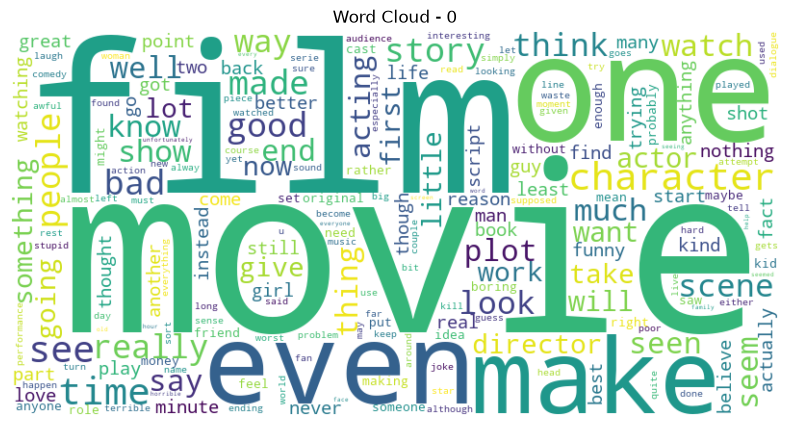

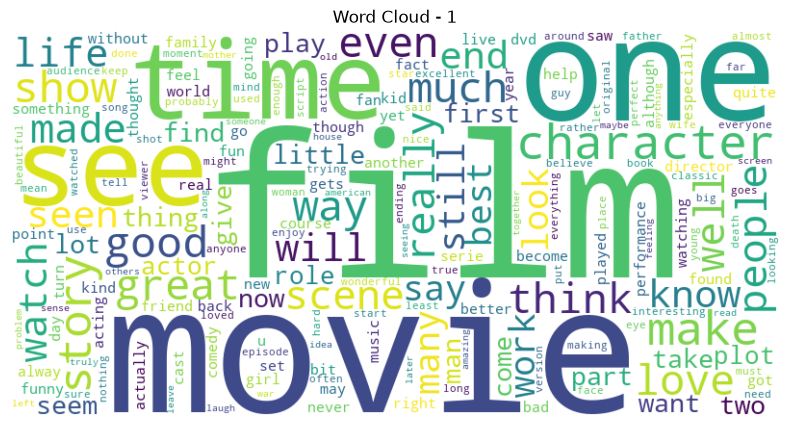

In [138]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for category in df["label"].unique():

    text = " ".join(df[df["label"] == category]["text"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {category}")
    plt.show()

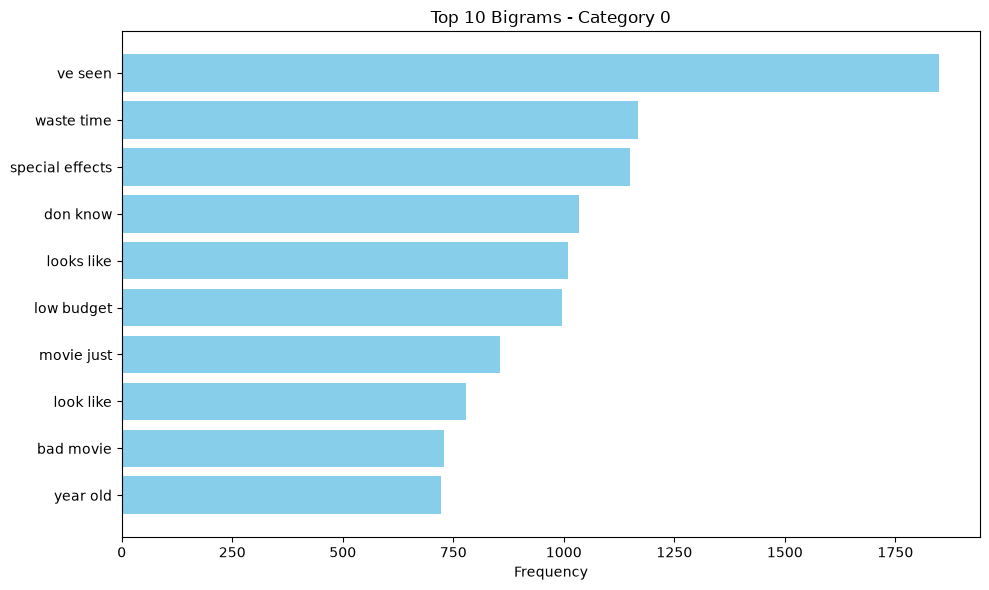


Top 10 Bigrams for Category 0:
ve seen: 1849
waste time: 1168
special effects: 1149
don know: 1034
looks like: 1010
low budget: 995
movie just: 855
look like: 778
bad movie: 728
year old: 723


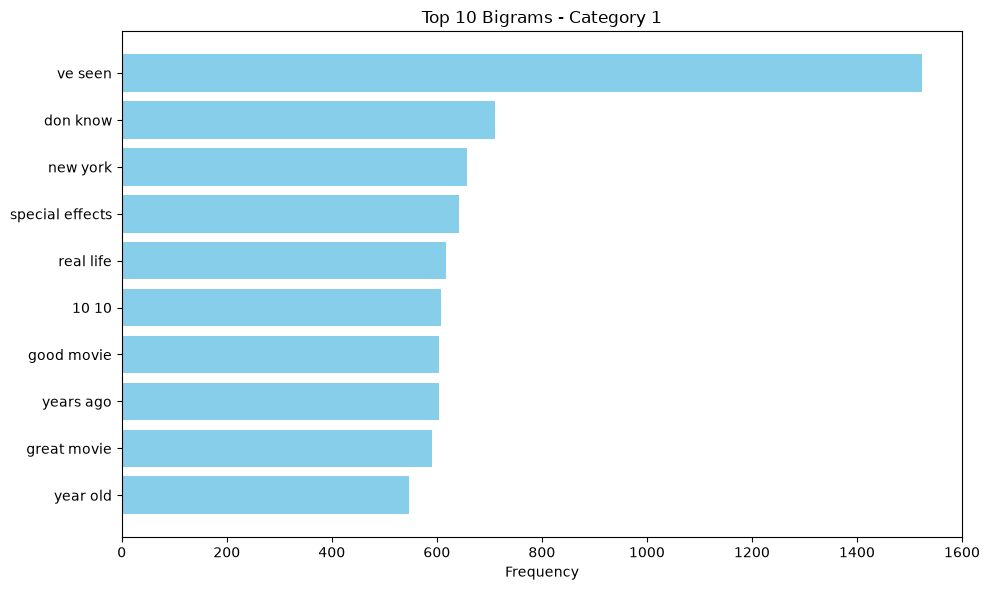


Top 10 Bigrams for Category 1:
ve seen: 1524
don know: 711
new york: 658
special effects: 643
real life: 618
10 10: 608
good movie: 605
years ago: 604
great movie: 590
year old: 547


In [139]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Assuming your DataFrame has a 'label' or 'sentiment' column for categories
# If your column name is different (e.g. 'label', 'sentiment', 'class'), change it accordingly

for category in sorted(df["label"].unique()):   # Change "label" to your actual category column
    
    # Get text for this category only
    text_data = df[df["label"] == category]["text"]
    
    # Create bigrams
    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words='english',      # Optional: remove common English stop words
        min_df=2                   # Ignore very rare bigrams
    )
    
    ngrams = vectorizer.fit_transform(text_data)
    
    # Count frequency
    ngram_counts = ngrams.sum(axis=0)
    
    # Get bigram names and frequencies
    ngram_freq = [
        (word, ngram_counts[0, idx])
        for word, idx in vectorizer.vocabulary_.items()
    ]
    
    # Sort by frequency (descending)
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)
    
    # Plot top 10 bigrams
    top_ngrams = ngram_freq[:10]
    
    if not top_ngrams:
        print(f"No bigrams found for category: {category}")
        continue
        
    words = [x[0] for x in top_ngrams]
    counts = [x[1] for x in top_ngrams]

    plt.figure(figsize=(10, 6))
    plt.barh(words, counts, color='skyblue')
    plt.xlabel("Frequency")
    plt.title(f"Top 10 Bigrams - Category {category}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Optional: Print top 10 bigrams
    print(f"\nTop 10 Bigrams for Category {category}:")
    for word, count in top_ngrams:
        print(f"{word}: {count}")

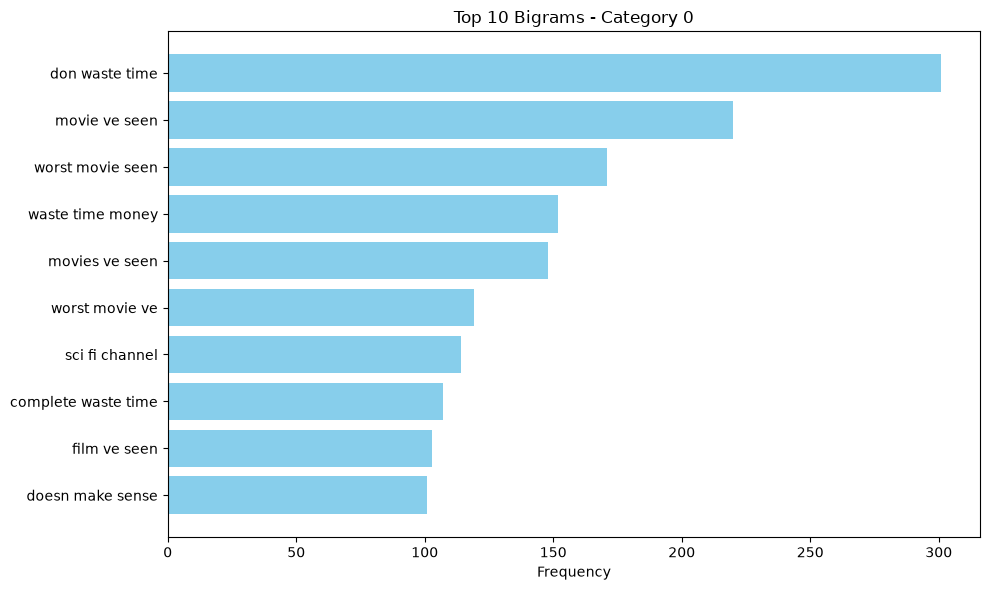


Top 10 Bigrams for Category 0:
don waste time: 301
movie ve seen: 220
worst movie seen: 171
waste time money: 152
movies ve seen: 148
worst movie ve: 119
sci fi channel: 114
complete waste time: 107
film ve seen: 103
doesn make sense: 101


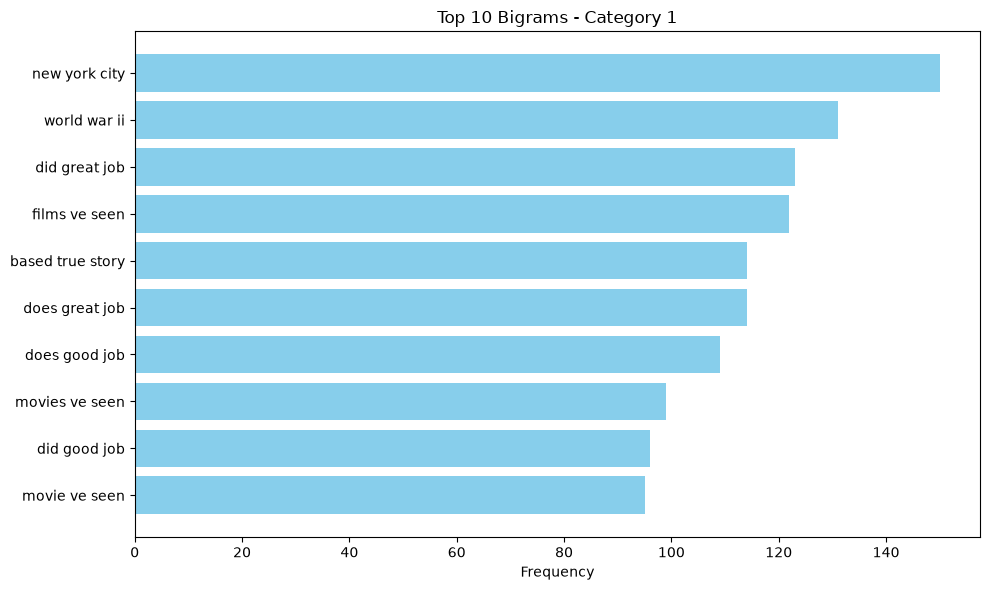


Top 10 Bigrams for Category 1:
new york city: 150
world war ii: 131
did great job: 123
films ve seen: 122
based true story: 114
does great job: 114
does good job: 109
movies ve seen: 99
did good job: 96
movie ve seen: 95


In [140]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Assuming your DataFrame has a 'label' or 'sentiment' column for categories
# If your column name is different (e.g. 'label', 'sentiment', 'class'), change it accordingly

for category in sorted(df["label"].unique()):   # Change "label" to your actual category column
    
    # Get text for this category only
    text_data = df[df["label"] == category]["text"]
    
    # Create bigrams
    vectorizer = CountVectorizer(
        ngram_range=(3, 3),
        stop_words='english',      # Optional: remove common English stop words
        min_df=2                   # Ignore very rare bigrams
    )
    
    ngrams = vectorizer.fit_transform(text_data)
    
    # Count frequency
    ngram_counts = ngrams.sum(axis=0)
    
    # Get bigram names and frequencies
    ngram_freq = [
        (word, ngram_counts[0, idx])
        for word, idx in vectorizer.vocabulary_.items()
    ]
    
    # Sort by frequency (descending)
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)
    
    # Plot top 10 bigrams
    top_ngrams = ngram_freq[:10]
    
    if not top_ngrams:
        print(f"No bigrams found for category: {category}")
        continue
        
    words = [x[0] for x in top_ngrams]
    counts = [x[1] for x in top_ngrams]

    plt.figure(figsize=(10, 6))
    plt.barh(words, counts, color='skyblue')
    plt.xlabel("Frequency")
    plt.title(f"Top 10 Bigrams - Category {category}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Optional: Print top 10 bigrams
    print(f"\nTop 10 Bigrams for Category {category}:")
    for word, count in top_ngrams:
        print(f"{word}: {count}")

In [141]:
df["label"]

0        0
1        0
2        0
3        0
4        1
        ..
39995    1
39996    1
39997    0
39998    1
39999    1
Name: label, Length: 40000, dtype: int64

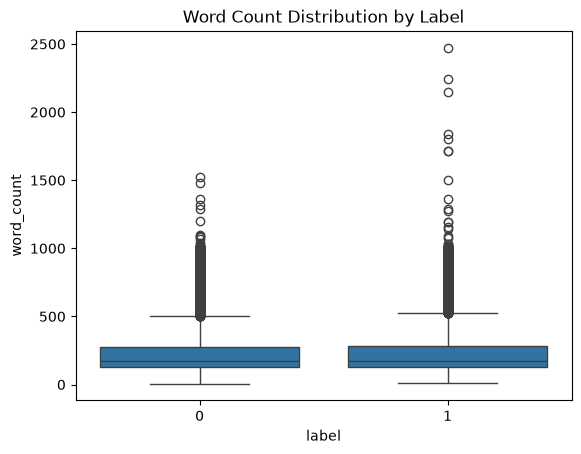

In [143]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(x="label", y="word_count", data=df)

plt.title("Word Count Distribution by Label")
plt.show()

In [144]:
before = len(df)

df = df[df["word_count"] <= 500]

after = len(df)

print(f"Removed {before - after} rows")
print(f"Remaining rows: {after}")

Removed 3139 rows
Remaining rows: 36861


In [ ]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(x="label", y="word_count", data=df)

plt.title("Word Count Distribution by Label")
plt.show()

In [145]:
print("Column names in your data:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Column names in your data:
['label', 'text', 'word_count']

First 5 rows:
   label                                               text  word_count
0      0  i grew up b 1965 watching and loving the thund...         151
1      0  when i put this movie in my dvd player and sat...         332
2      0  why do people who do not know what a particula...         186
3      0  even though i have great interest in biblical ...          69
4      1  im a die hard dads army fan and nothing will e...         173


In [146]:

# Check class distribution
print(df["label"].value_counts())

# Percentage distribution
print(
    df["label"].value_counts(normalize=True) * 100
)

label
0    18589
1    18272
Name: count, dtype: int64
label
0    50.429994
1    49.570006
Name: proportion, dtype: float64


In [147]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer


word = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=100000
)


char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=50000
)


X_word = word.fit_transform(df["text"])

X_char = char.fit_transform(df["text"])


X = hstack([
    X_word,
    X_char
])



In [148]:
y = df["label"]

In [149]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [150]:
# Linear Models
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    PassiveAggressiveClassifier,
    RidgeClassifier,
    Perceptron
)

# SVM
from sklearn.svm import (
    LinearSVC,
    SVC
)

# Naive Bayes
from sklearn.naive_bayes import (
    MultinomialNB,
    ComplementNB,
    BernoulliNB,
    GaussianNB
)

# Nearest Neighbors
from sklearn.neighbors import (
    KNeighborsClassifier,
    RadiusNeighborsClassifier
)

# Tree Models
from sklearn.tree import (
    DecisionTreeClassifier,
    ExtraTreeClassifier
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Discriminant Analysis
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# Neural Network
from sklearn.neural_network import MLPClassifier

# External Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


models = {

    # ==========================
    # Sparse Matrix Friendly ⭐
    # ==========================

    "LogisticRegression": LogisticRegression(
        max_iter=1000
    ),

    "LogisticRegression_balanced": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "LinearSVC": LinearSVC(),

    "LinearSVC_balanced": LinearSVC(
        class_weight="balanced"
    ),

    "SGDClassifier": SGDClassifier(
        loss="hinge"
    ),

    "PassiveAggressiveClassifier": PassiveAggressiveClassifier(),

    "RidgeClassifier": RidgeClassifier(),

    "Perceptron": Perceptron(),

    "MultinomialNB": MultinomialNB(),

    "ComplementNB": ComplementNB(),




}

c:\Users\Alvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [151]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score 

In [152]:
result = []
for name,model in models.items():
    model.fit(X_train,y_train)
    predict = model.predict(X_test)
    acc = accuracy_score(predict,y_test)
    
    precision = precision_score(y_test,predict)

    recall = recall_score(y_test,predict)

    f1 = f1_score(y_test,predict)

    print(f"{name} Accuracy:{acc} Precision:{precision} Recall:{recall} F1:{f1}")
    result.append({
    "Name": name,
    "Accuracy": acc,
    "Recall": recall,
    "F1": f1
    })




LogisticRegression Accuracy:0.9037402383888203 Precision:0.8964889036104671 Recall:0.9083738882362813 F1:0.9023922647328498
LogisticRegression_balanced Accuracy:0.9034114262227703 Precision:0.896551724137931 Recall:0.9075348212787381 F1:0.9020098407138687
LinearSVC Accuracy:0.9064529387587341 Precision:0.9026223484215801 Recall:0.9068635677127035 F1:0.9047379876109158
LinearSVC_balanced Accuracy:0.9064529387587341 Precision:0.9023535302954432 Recall:0.9071991944957207 F1:0.9047698744769874
SGDClassifier Accuracy:0.9071105630908344 Precision:0.8967953985209531 Recall:0.9157576774626616 F1:0.9061773497177018
PassiveAggressiveClassifier Accuracy:0.9011919441019318 Precision:0.899144151703306 Recall:0.899144151703306 F1:0.899144151703306
RidgeClassifier Accuracy:0.905219893136046 Precision:0.8994348404255319 Recall:0.9080382614532639 F1:0.9037160751565761
Perceptron Accuracy:0.8896835182901768 Precision:0.8764063264307843 Recall:0.9019969793589528 F1:0.8890175322527291
MultinomialNB Accura

In [153]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'l1_ratio': [0.0, 0.15, 0.5, 0.85, 1.0],           # only relevant for elasticnet
    'learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'eta0': [0.01, 0.1, 0.5],
    'max_iter': [1000, 5000],
    'early_stopping': [True, False],
}



sgd = SGDClassifier(random_state=42)

random_search = RandomizedSearchCV(
    sgd, 
    param_distributions=param_grid, 
    n_iter=30,          # adjust based on time budget
    cv=5, 
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [1e-05, 0.0001, ...], 'early_stopping': [True, False], 'eta0': [0.01, 0.1, ...], 'l1_ratio': [0.0, 0.15, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple 

In [154]:
random_search.best_params_

{'penalty': 'l2',
 'max_iter': 5000,
 'loss': 'hinge',
 'learning_rate': 'optimal',
 'l1_ratio': 1.0,
 'eta0': 0.1,
 'early_stopping': False,
 'alpha': 0.0001}

## How this algorithm works?
- SGDClassifier (Stochastic Gradient Descent Classifier) is a linear classification algorithm that learns by updating its model parameters (weights) after processing one training sample at a time (or a very small batch). Instead of using the entire dataset for each update, it computes the prediction, calculates the loss, computes the gradient, and updates the weights iteratively. This makes it fast, memory-efficient, and well-suited for large datasets and online learning. The type of classifier depends on the loss function (e.g., log_loss for Logistic Regression, hinge for Linear SVM).

In [167]:
sgd = SGDClassifier(penalty='l2',max_iter= 5000,loss= 'hinge',learning_rate= 'optimal',l1_ratio= 1,eta0= 0.1,early_stopping= False,alpha= 0.0001)
sgd.fit(X_train,y_train)
predict = sgd.predict(X_test)
acc = accuracy_score(predict,y_test)
    
precision = precision_score(y_test,predict)

recall = recall_score(y_test,predict)

f1 = f1_score(y_test,predict)

In [168]:
acc*100,precision*100,recall*100,f1*100

(90.8754623921085, 90.52314892194552, 90.88773284108072, 90.70507452687991)

In [169]:
import pickle

# Assuming 'trained_model' is your fitted machine learning model
filename = 'SGD_Model.pkl'

# Save the model to disk
with open(filename, 'wb') as file:
    pickle.dump(sgd, file)
with open("Char_vector.pkl", 'wb') as file:
    pickle.dump(char, file)
with open("Word_vector.pkl", 'wb') as file:
    pickle.dump(word,file)

